# Base Optimization Project

## Model Overview

In [1]:
from aerialdrm.wildfire.fireenvironment import FireMap, FireEnvironment, FirePropagation, sim_properties

### Fire Map/Propagation

`FireMap` defines the map that the fire propagates over. 

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

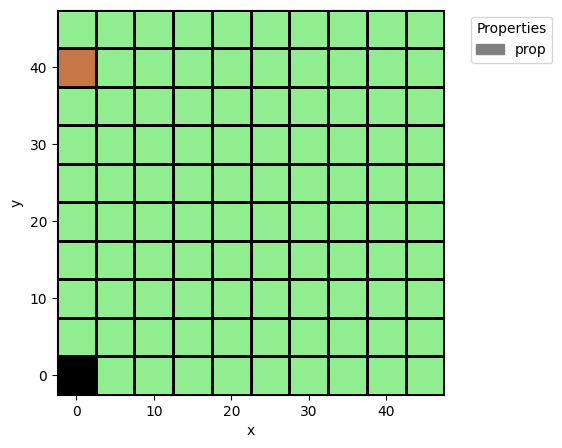

In [2]:
fm = FireMap()
fm

fm.show(sim_properties)


`FireMap` has a number of parameters that can be modified to simulate different types of fires:

In [3]:
fm.p
import inspect
print(inspect.getsource(fm.p.__class__))

class FireMapParam(CoordsParam):
    x_size: int = 10
    y_size: int = 10
    blocksize: float = 5.0  # 5 kilometers
    state_to_burn: tuple = (float, np.nan)
    state_burning: tuple = (bool, False)
    state_to_extinguish: tuple = (float, np.nan)
    state_extinguished: tuple = (bool, False)
    feature_strike: tuple = (bool, False)
    feature_grass: tuple = (bool, False)
    feature_scrub: tuple = (bool, False)
    feature_forest: tuple = (bool, False)
    feature_water: tuple = (bool, False)
    feature_base: tuple = (bool, False)
    base_locations: tuple = ((0.0, 0.0),)
    num_strikes: int = 1
    map_type: str = "uniform-grass"
    grass_ig_time: float = 50.0  # 5 km every 50 timesteps (~3mph)
    grass_ex_time: float = 90.0
    scrub_ig_time: float = 75.0
    scrub_ex_time: float = 200.0
    forest_ig_time: float = 100.0
    forest_ex_time: float = 400.0



The strike location is determined at the start of the simulation to be random based on the number of strikes.

We can chose between a few different types of firemaps as follows:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

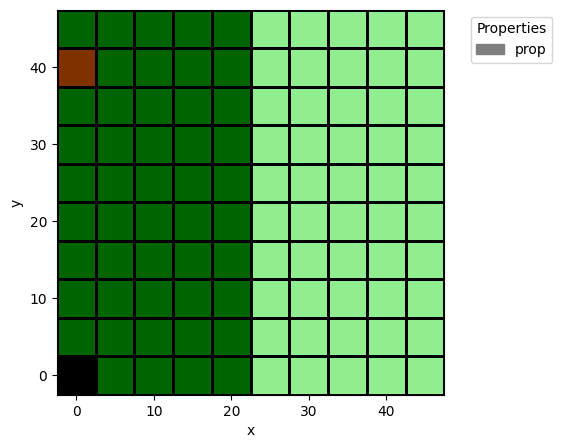

In [4]:
fm_bi = FireMap(p={'map_type': 'split-forest-grass'})
fm_bi.show(sim_properties)

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

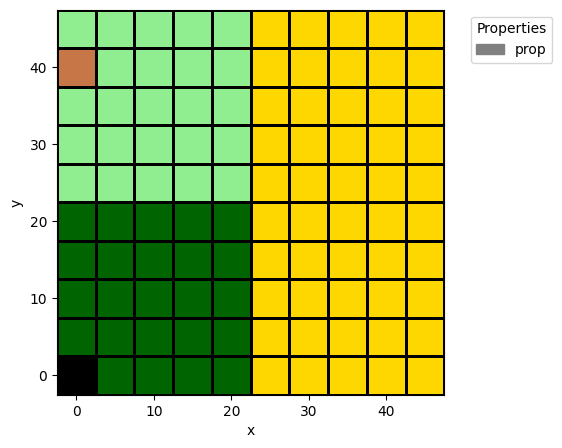

In [5]:
fm_tri = FireMap(p={'map_type': 'forest-grass-scrub'})
fm_tri.show(sim_properties)

we can also add base locations:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

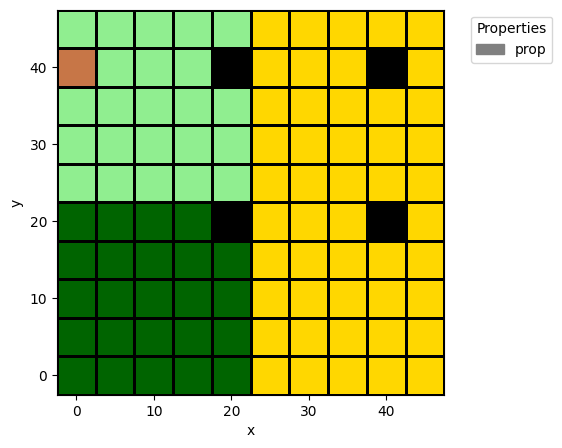

In [6]:
fm_bases = FireMap(p={'map_type': 'forest-grass-scrub', 'base_locations': ((20, 20),( 40, 40), (20, 40), (40, 20))})
fm_bases.show(sim_properties)

and add more or less strike locations:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

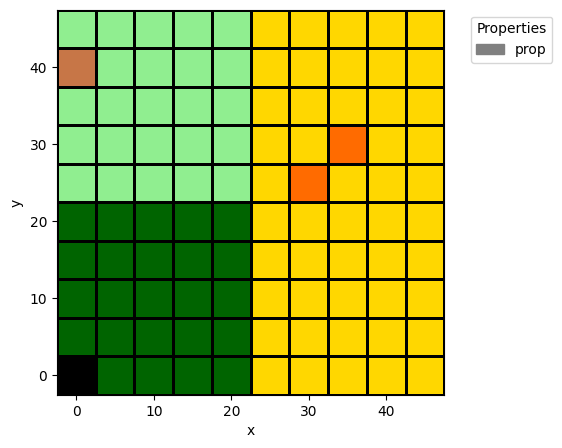

In [7]:
fm_three_strike = FireMap(p={'map_type': 'forest-grass-scrub', 'num_strikes': 3})
fm_three_strike.show(sim_properties)

Different samples can further be drawn by changing the random seed:

(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

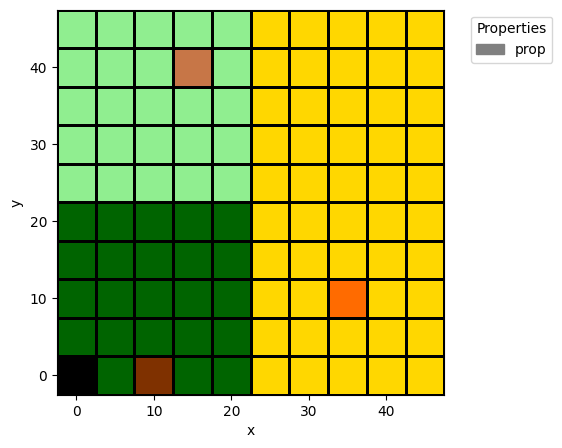

In [8]:
fm_three_strike = FireMap(p={'map_type': 'forest-grass-scrub', 'num_strikes': 3}, r={'seed': 250})
fm_three_strike.show(sim_properties)

Propagation of the fire is called from `FirePropagation`. 

In [9]:
fp = FirePropagation(track='all', fireenvironment=FireEnvironment(c={'p': {'map_type': 'forest-grass-scrub', 'num_strikes': 3}}))
fp

firepropagation FirePropagation
- FirePropagationState(perc_burned=0.0, leading_edge_length=0)

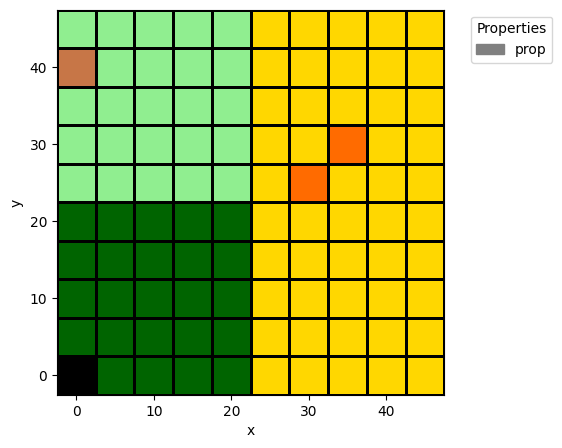

In [10]:
fig, ax = fp.fireenvironment.c.show(properties=sim_properties)

Below we simulate and visualize the propagation of the fire over time:

In [11]:
from fmdtools.sim import propagate

In [12]:
res, hist = propagate.nominal(fp, protect=False)

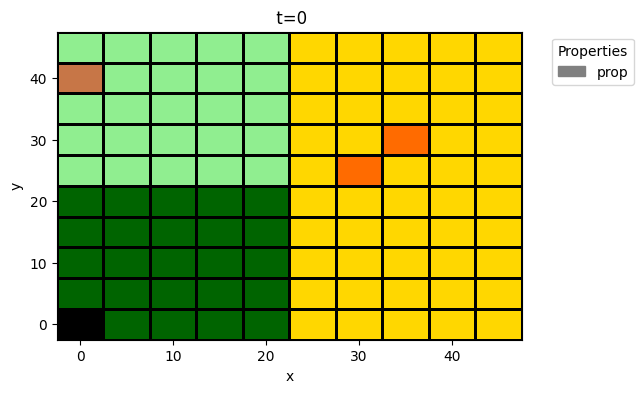

In [13]:
from IPython.display import HTML
ani = fp.fireenvironment.c.animate(hist.fireenvironment.c, properties=sim_properties)
HTML(ani.to_jshtml())

### Aircraft 

Aircraft fly from bases to mitigate the fire. They are defined in the `Aircraft` module.class

In [14]:
from aerialdrm.wildfire.fireaircraft import FireAircraft

In [15]:
fe = FireEnvironment(c={"p": {"base_locations": ((40.0, 20.0),), "num_strikes": 3}})
fe.prop_time()
a1 = FireAircraft(s={'goal_x': 30, 'goal_y': 40}, fireenvironment=fe, track="all")

Below we simulate the aircraft responding to a (non-propagating) fire:

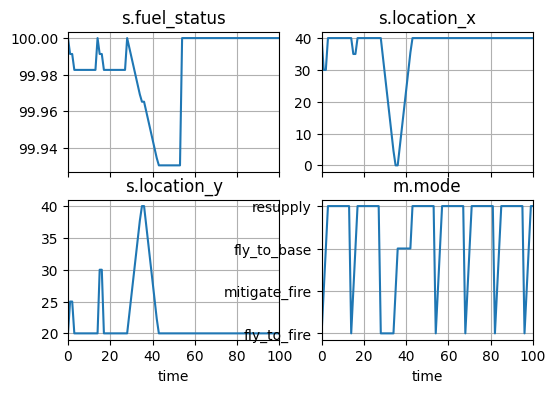

In [16]:
res, hist = propagate.nominal(a1, protect=False)
fig, ax = hist.plot_line('s.fuel_status', 's.location_x', 's.location_y', 'm.mode')

As shown above, the aircraft alternates between flying, mitigating, and resupplying, and resupply can take some time.

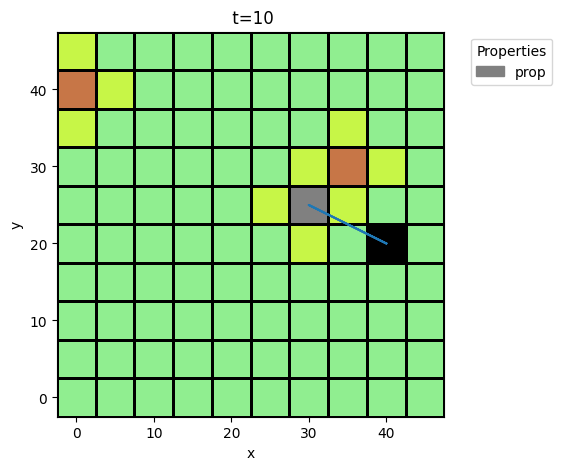

In [17]:
fig, ax = a1.fireenvironment.c.show_from(10, hist.fireenvironment.c, properties=sim_properties)
hist2 = hist.cut(10, newcopy=True)
hist2.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

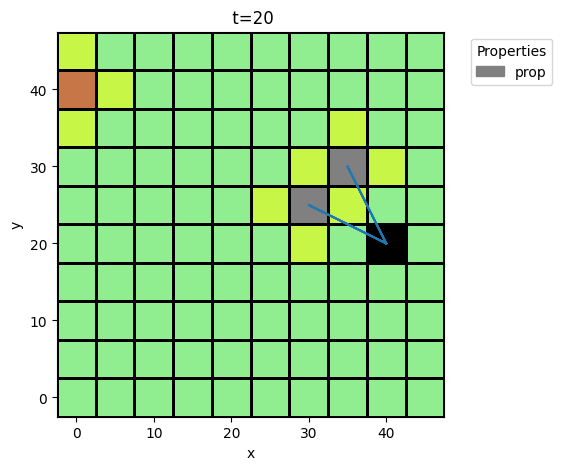

In [18]:
fig, ax = a1.fireenvironment.c.show_from(20, hist.fireenvironment.c, properties=sim_properties)
hist2 = hist.cut(20, newcopy=True)
hist2.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

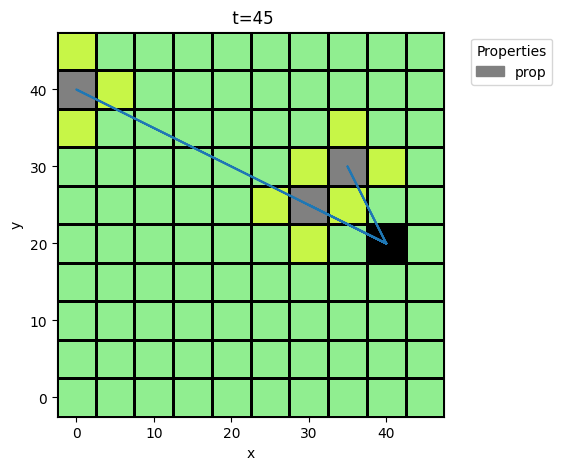

In [19]:
fig, ax = a1.fireenvironment.c.show_from(45, hist.fireenvironment.c, properties=sim_properties)
hist2 = hist.cut(45, newcopy=True)
hist2.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

### Combined Simulation

In [20]:
from aerialdrm.wildfire.wildfiresim import WildfireSim

In [21]:
mdl = WildfireSim()

This integrated model has both firepropagation as well as aircraft. We can change the number of aircraft by changing the number of bases.

(<Figure size 1200x1000 with 1 Axes>, <Axes: >)

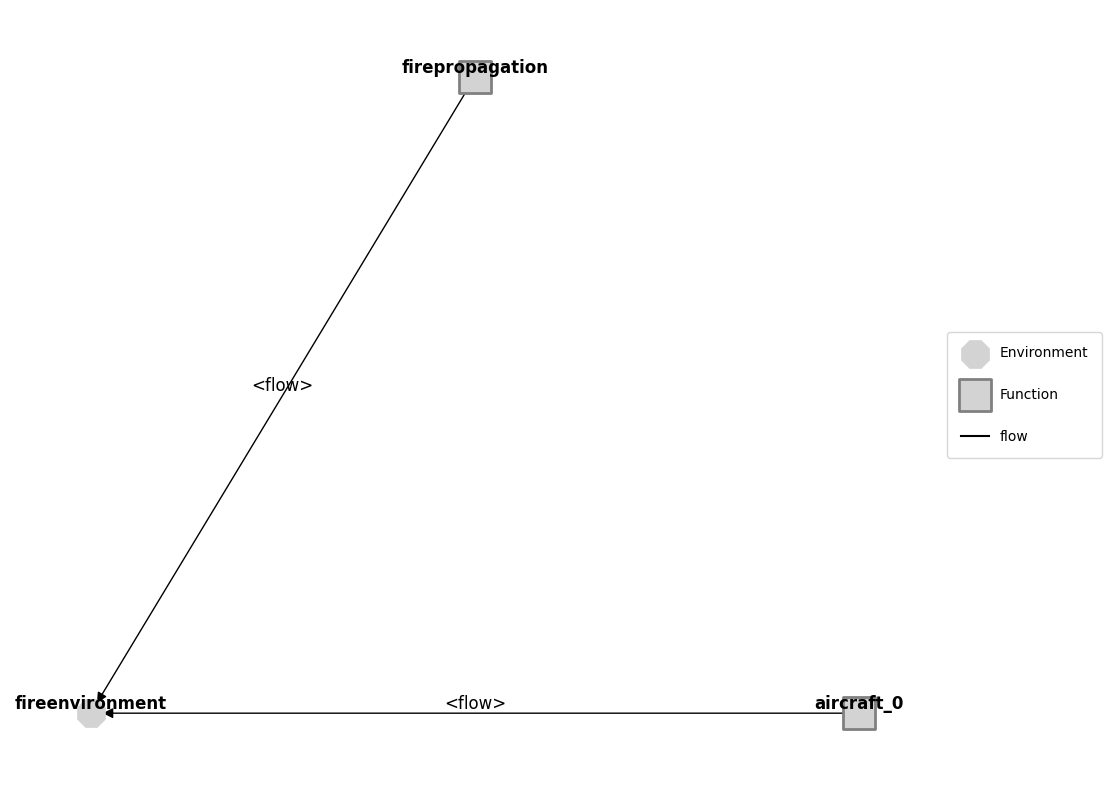

In [22]:
from fmdtools.define.architecture.function import FunctionArchitectureGraph
mdl_graph = FunctionArchitectureGraph(mdl)
mdl_graph.draw()

(<Figure size 1200x1000 with 1 Axes>, <Axes: >)

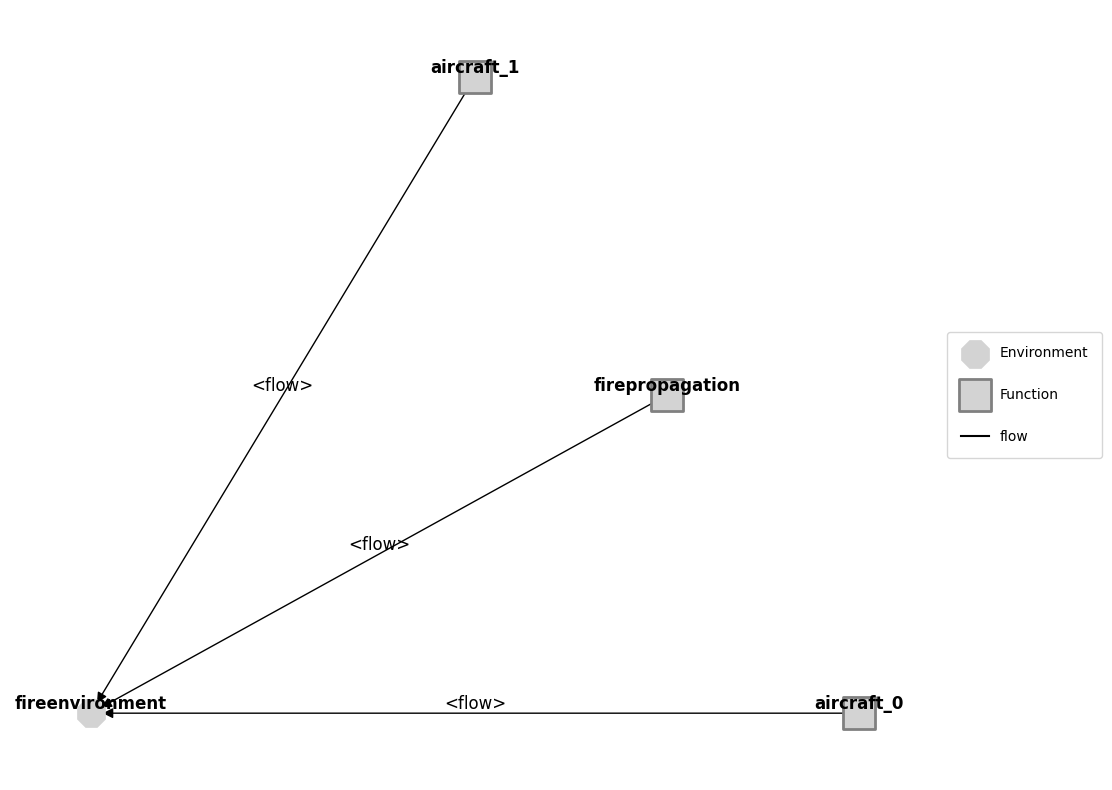

In [23]:
mdl2 = WildfireSim(p = {'firemapparam': {'base_locations': ((30, 30), (40, 40))}})
mdl2_graph = FunctionArchitectureGraph(mdl2)
mdl2_graph.draw()

Below we simulate the combined propagation and suppression of the fire

In [24]:
mdl = WildfireSim(p = {'firemapparam': {'num_strikes': 4,
                        'base_locations': ((0, 45),),
                         'map_type': 'grass-forest-scrub'}})
res, hist = propagate.nominal(mdl, protect=False)

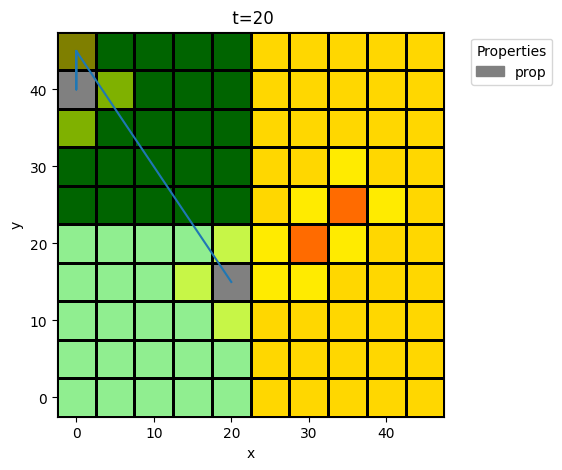

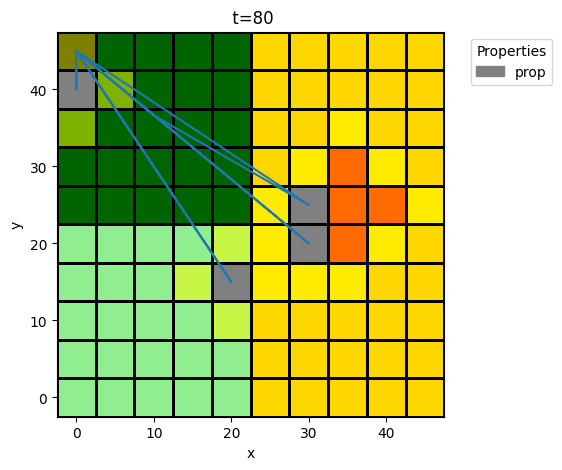

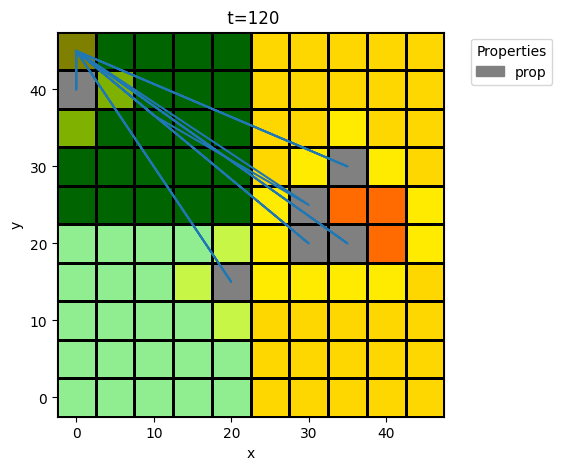

In [25]:
fig, ax = mdl.flows['fireenvironment'].c.show_from(20, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(20, newcopy=True)
hist20.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

fig, ax = mdl.flows['fireenvironment'].c.show_from(80, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(80, newcopy=True)
hist20.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

fig, ax = mdl.flows['fireenvironment'].c.show_from(120, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(120, newcopy=True)
hist20.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

With two aircraft bases, the fire is put out more quickly:

In [26]:
mdl = WildfireSim(p = {'firemapparam': {'num_strikes': 4,
                        'base_locations': ((0, 45), (0, 0)),
                         'map_type': 'grass-forest-scrub'}})
res, hist = propagate.nominal(mdl, protect=False)

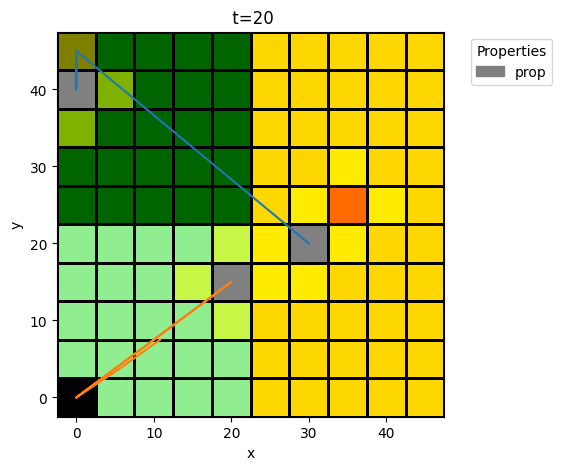

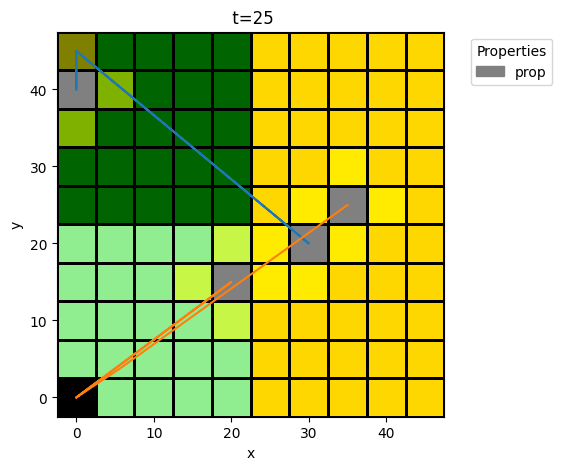

In [27]:
fig, ax = mdl.flows['fireenvironment'].c.show_from(20, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist20 = hist.cut(20, newcopy=True)
hist20.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

fig, ax = mdl.flows['fireenvironment'].c.show_from(25, hist.flows.fireenvironment.c,
                                                   properties=sim_properties)
hist80 = hist.cut(80, newcopy=True)
hist80.plot_trajectory('s.location_x', 's.location_y', fig=fig, ax=ax)

#### Optimization

We can perform optimization by defining a problem to solve. Below the problem is to minimize burned area with a single base placement given random strikes.

In [28]:
from aerialdrm.wildfire.wildfiresim import BasePlacementProblem

psp = BasePlacementProblem(track='all', p={'firemapparam': {'num_strikes': 4}}, seed=1)
psp.perc_burned(10, 10)

0.11300000000000002

In [29]:
psp

BasePlacementProblem with:
VARIABLES
 -x                                                         10.0000
 -y                                                         10.0000
OBJECTIVES
 -perc_burned                                                0.1130

The above number is the average percent burned over 10 random seeds. We can see the objective over all scenarios below:

In [30]:
psp.res

rep0_var_0.end.endclass.perc_burned: 0.09
rep0_var_0.end.endclass.burn_pts: array(10)
rep0_var_0.end.fxns.                0.09
rep1_var_1.end.endclass.perc_burned: 0.06
rep1_var_1.end.endclass.burn_pts: array(10)
rep1_var_1.end.fxns.                0.06
rep2_var_2.end.endclass.perc_burned: 0.18
rep2_var_2.end.endclass.burn_pts: array(10)
rep2_var_2.end.fxns.                0.18
rep3_var_3.end.endclass.perc_burned: 0.13
rep3_var_3.end.endclass.burn_pts: array(10)
rep3_var_3.end.fxns.                0.13
rep4_var_4.end.endclass.perc_burned: 0.15
rep4_var_4.end.endclass.burn_pts: array(10)
rep4_var_4.end.fxns.                0.15
rep5_var_5.end.endclass.perc_burned: 0.11
rep5_var_5.end.endclass.burn_pts: array(10)
rep5_var_5.end.fxns.                0.11
rep6_var_6.end.endclass.perc_burned: 0.18
rep6_var_6.end.endclass.burn_pts: array(10)
rep6_var_6.end.fxns.                0.18
rep7_var_7.end.endclass.perc_burned: 0.04
rep7_var_7.end.endclass.burn_pts: array(10)
rep7_var_7.end.fxns.     

as well as evaluate the function over different base placements:

In [31]:
psp.perc_burned(40, 10)

0.138

In [32]:
psp.perc_burned(40, 20)

0.11900000000000002

In [33]:
psp.perc_burned(20, 20)

0.07300000000000001

In [34]:
psp.res

rep0_var_0.end.endclass.perc_burned: 0.07
rep0_var_0.end.endclass.burn_pts: array(10)
rep0_var_0.end.fxns.                0.07
rep1_var_1.end.endclass.perc_burned: 0.06
rep1_var_1.end.endclass.burn_pts: array(10)
rep1_var_1.end.fxns.                0.06
rep2_var_2.end.endclass.perc_burned: 0.07
rep2_var_2.end.endclass.burn_pts: array(10)
rep2_var_2.end.fxns.                0.07
rep3_var_3.end.endclass.perc_burned: 0.04
rep3_var_3.end.endclass.burn_pts: array(10)
rep3_var_3.end.fxns.                0.04
rep4_var_4.end.endclass.perc_burned: 0.08
rep4_var_4.end.endclass.burn_pts: array(10)
rep4_var_4.end.fxns.                0.08
rep5_var_5.end.endclass.perc_burned: 0.04
rep5_var_5.end.endclass.burn_pts: array(10)
rep5_var_5.end.fxns.                0.04
rep6_var_6.end.endclass.perc_burned: 0.14
rep6_var_6.end.endclass.burn_pts: array(10)
rep6_var_6.end.fxns.                0.14
rep7_var_7.end.endclass.perc_burned: 0.07
rep7_var_7.end.endclass.burn_pts: array(10)
rep7_var_7.end.fxns.     

In [35]:
psp.parameterdomain(10, 10)

WildFireSimParameter(firemapparam=FireMapParam(x_size=10, y_size=10, blocksize=5.0, state_to_burn=(<class 'float'>, nan), state_burning=(<class 'bool'>, False), state_to_extinguish=(<class 'float'>, nan), state_extinguished=(<class 'bool'>, False), feature_strike=(<class 'bool'>, False), feature_grass=(<class 'bool'>, False), feature_scrub=(<class 'bool'>, False), feature_forest=(<class 'bool'>, False), feature_water=(<class 'bool'>, False), feature_base=(<class 'bool'>, False), base_locations=((10, 10),), num_strikes=4, map_type='uniform-grass', grass_ig_time=50.0, grass_ex_time=90.0, scrub_ig_time=75.0, scrub_ex_time=200.0, forest_ig_time=100.0, forest_ex_time=400.0))

In [36]:
psp.sim_mdl

<bound method ParameterSimProblem.sim_mdl of BasePlacementProblem with:
VARIABLES
 -x                                                         20.0000
 -y                                                         20.0000
OBJECTIVES
 -perc_burned                                                0.0730>

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': ' t=10'}, xlabel='x', ylabel='y'>)

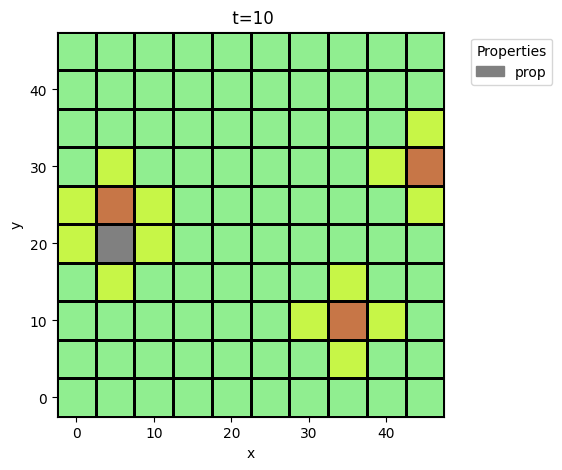

In [37]:
show_properties = {k:v for k,v in sim_properties.items() if k!="base"}
psp.mdl.flows['fireenvironment'].c.show_from(10, psp.hist.rep0_var_0.flows.fireenvironment.c, show_properties)

In [38]:
psp.hist.rep0_var_0.flows.fireenvironment.c.burning[0].shape

(10, 10)

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': ' t=35'}, xlabel='x', ylabel='y'>)

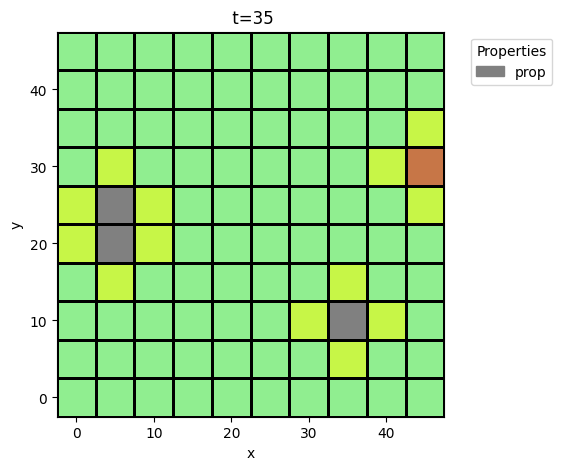

In [39]:
psp.mdl.flows['fireenvironment'].c.show_from(35, psp.hist.rep0_var_0.flows.fireenvironment.c, show_properties)